<a href="https://colab.research.google.com/github/faisu6339-glitch/Deep-Learning/blob/main/Customer_Churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [46]:
import pandas as pd
import numpy as np

In [47]:
df=pd.read_csv('Churn_Modelling.csv')

In [48]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [50]:
df.isnull().mean()*100

,0
RowNumber,0.0
CustomerId,0.0
Surname,0.0
CreditScore,0.0
Geography,0.0
Gender,0.0
Age,0.0
Tenure,0.0
Balance,0.0
NumOfProducts,0.0


In [51]:
df.duplicated().sum()

np.int64(0)

In [52]:
df['Exited'].value_counts()

,count
Exited,
0,7963
1,2037


In [53]:
df['Geography'].value_counts()

,count
Geography,
France,5014
Germany,2509
Spain,2477


In [54]:
df['Gender'].value_counts()

,count
Gender,
Male,5457
Female,4543


In [55]:
df.drop(columns=["RowNumber","CustomerId","Surname"],inplace=True)

In [56]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [57]:
df=pd.get_dummies(df,columns=["Geography","Gender"],drop_first=True)

In [58]:
df

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,0,False,False,True
9996,516,35,10,57369.61,1,1,1,101699.77,0,False,False,True
9997,709,36,7,0.00,1,0,1,42085.58,1,False,False,False
9998,772,42,3,75075.31,2,1,0,92888.52,1,True,False,True


In [59]:
# Convert all boolean columns to integers
df = df.astype(int)

In [60]:
df

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0,1,1,1,101348,1,0,0,0
1,608,41,1,83807,1,0,1,112542,0,0,1,0
2,502,42,8,159660,3,1,0,113931,1,0,0,0
3,699,39,1,0,2,0,0,93826,0,0,0,0
4,850,43,2,125510,1,1,1,79084,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0,2,1,0,96270,0,0,0,1
9996,516,35,10,57369,1,1,1,101699,0,0,0,1
9997,709,36,7,0,1,0,1,42085,1,0,0,0
9998,772,42,3,75075,2,1,0,92888,1,1,0,1


In [61]:
X=df.drop(columns=["Exited"])
y=df["Exited"]


In [62]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [63]:
X

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0,1,1,1,101348,0,0,0
1,608,41,1,83807,1,0,1,112542,0,1,0
2,502,42,8,159660,3,1,0,113931,0,0,0
3,699,39,1,0,2,0,0,93826,0,0,0
4,850,43,2,125510,1,1,1,79084,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0,2,1,0,96270,0,0,1
9996,516,35,10,57369,1,1,1,101699,0,0,1
9997,709,36,7,0,1,0,1,42085,0,0,0
9998,772,42,3,75075,2,1,0,92888,1,0,1


In [64]:
y

,Exited
0,1
1,0
2,1
3,0
4,0
...,...
9995,0
9996,0
9997,1
9998,1


In [65]:
X_train.shape

(8000, 11)

In [66]:
y_test.shape

(2000,)

In [67]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train_scaled=sc.fit_transform(X_train)
X_test_scaled=sc.transform(X_test)

In [68]:
X_train_scaled

array([[ 0.35649971, -0.6557859 ,  0.34567966, ..., -0.57946723,
        -0.57638802,  0.91324755],
       [-0.20389777,  0.29493847, -0.3483691 , ...,  1.72572313,
        -0.57638802,  0.91324755],
       [-0.96147213, -1.41636539, -0.69539349, ..., -0.57946723,
         1.73494238,  0.91324755],
       ...,
       [ 0.86500853, -0.08535128, -1.38944225, ..., -0.57946723,
        -0.57638802, -1.09499335],
       [ 0.15932282,  0.3900109 ,  1.03972843, ..., -0.57946723,
        -0.57638802,  0.91324755],
       [ 0.47065475,  1.15059039, -1.38944225, ...,  1.72572313,
        -0.57638802,  0.91324755]])

In [69]:
X_test_scaled

array([[-0.57749609, -0.6557859 , -0.69539349, ...,  1.72572313,
        -0.57638802,  0.91324755],
       [-0.29729735,  0.3900109 , -1.38944225, ..., -0.57946723,
        -0.57638802,  0.91324755],
       [-0.52560743,  0.48508334, -0.3483691 , ..., -0.57946723,
         1.73494238, -1.09499335],
       ...,
       [ 0.81311987,  0.77030065,  0.69270405, ..., -0.57946723,
        -0.57638802, -1.09499335],
       [ 0.41876609, -0.94100321, -0.3483691 , ..., -0.57946723,
        -0.57638802,  0.91324755],
       [-0.24540869,  0.00972116, -1.38944225, ...,  1.72572313,
        -0.57638802,  0.91324755]])

In [70]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [71]:
model=Sequential()
#
model.add(Dense(32,activation="relu",input_dim=11))
model.add(Dense(16,activation="relu"))
model.add(Dense(1,activation="sigmoid"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [72]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 32)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 929 (3.63 KB)

 Trainable params: 929 (3.63 KB)

 Non-trainable params: 0 (0.00 B)

In [73]:
model.compile(optimizer="Adam",loss="binary_crossentropy",metrics=["accuracy"])

In [74]:
model.fit(X_train_scaled,y_train,epochs=20,verbose=1)

Epoch 1/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7896 - loss: 0.4874
Epoch 2/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8238 - loss: 0.4187
Epoch 3/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8396 - loss: 0.3920
Epoch 4/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8487 - loss: 0.3663
Epoch 5/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8577 - loss: 0.3502
Epoch 6/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8611 - loss: 0.3426
Epoch 7/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8610 - loss: 0.3384
Epoch 8/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8615 - loss: 0.3358
Epoch 9/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8626 - loss: 0.3334
Epoch 10/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8637 - loss: 0.3314
Epoch 11/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8640 - loss: 0.3305
Epoch 12/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

In [75]:
model.layers[0].get_weights()


[array([[ 4.68004346e-01, -1.57008413e-02,  5.65638952e-02,
          2.29427934e-01,  5.89701831e-02,  1.17730260e-01,
         -3.93145494e-02,  3.20272446e-01,  4.77644913e-02,
         -9.08523276e-02, -2.82946318e-01,  2.62339115e-01,
         -2.56821848e-02, -1.51401415e-01, -2.04463914e-01,
          1.57435715e-01, -3.03955581e-02, -1.43312812e-01,
          1.33497983e-01, -1.02910228e-01,  2.02660412e-02,
         -5.60874104e-01,  3.68450999e-01,  3.62171352e-01,
          1.14176661e-01, -1.61559526e-02,  1.69532686e-01,
          1.60090715e-01, -2.07493007e-01,  2.22283602e-01,
          4.27379340e-01, -8.34637433e-02],
        [-5.00937440e-02,  7.61301875e-01,  6.64875805e-01,
         -2.02148899e-01,  2.21554592e-01, -1.40592068e-01,
         -2.17635259e-01, -2.41224557e-01, -3.31426561e-01,
          7.42631197e-01, -2.34082267e-01, -4.21805590e-01,
         -4.13165092e-01, -1.68278292e-01,  5.42779028e-01,
         -1.29302440e-04, -3.15051943e-01, -3.87149930e-

In [76]:
model.layers[1].get_weights()


[array([[-0.1303835 ,  0.22353862, -0.09249947, -0.12102391,  0.03248196,
          0.21825738,  0.34951174,  0.26083845,  0.02296564,  0.11583655,
          0.312693  , -0.44206068,  0.21488328,  0.28249413,  0.22317407,
         -0.00992862],
        [-0.01459804,  0.08180391,  0.04258817,  0.15139411,  0.43484288,
         -0.09303026, -0.20950083,  0.20804685, -0.01514959, -0.305103  ,
          0.04974242, -0.4937466 ,  0.06193869, -0.22991484,  0.34873447,
          0.2796275 ],
        [-0.24517266, -0.12175845,  0.28117856,  0.10536035,  0.46857923,
         -0.3742006 , -0.16628985,  0.04786791, -0.30794865, -0.39481187,
          0.30706507, -0.28559294, -0.19399542, -0.23216547,  0.24284919,
         -0.08624357],
        [ 0.2457125 , -0.21595338,  0.3086696 ,  0.00521191, -0.0925514 ,
          0.03953972, -0.36576796, -0.069568  ,  0.24017261,  0.47328597,
          0.22699071, -0.26449704,  0.358378  , -0.10629439,  0.29781124,
         -0.14646488],
        [ 0.12897506

In [77]:
model.layers[2].get_weights()
#

[array([[ 0.4405633 ],
        [-0.4433439 ],
        [-0.5152454 ],
        [ 0.68815666],
        [-0.89866513],
        [-0.49821287],
        [ 0.7413885 ],
        [-0.27452618],
        [-0.30663654],
        [-0.61561817],
        [ 0.71392477],
        [-0.7219852 ],
        [-0.188137  ],
        [-0.5338881 ],
        [ 0.5537998 ],
        [ 0.4293568 ]], dtype=float32),
 array([-0.10060932], dtype=float32)]

In [78]:
model.predict(X_test_scaled)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


array([[0.02263144],
       [0.01198114],
       [0.08641633],
       ...,
       [0.6344643 ],
       [0.10941343],
       [0.23458584]], dtype=float32)

In [84]:
history=model.fit(X_train_scaled,y_train,epochs=20,verbose=1,validation_split=0.2)

Epoch 1/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8695 - loss: 0.3203 - val_accuracy: 0.8625 - val_loss: 0.3156
Epoch 2/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8702 - loss: 0.3182 - val_accuracy: 0.8631 - val_loss: 0.3203
Epoch 3/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8698 - loss: 0.3185 - val_accuracy: 0.8612 - val_loss: 0.3218
Epoch 4/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8705 - loss: 0.3169 - val_accuracy: 0.8631 - val_loss: 0.3235
Epoch 5/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8680 - loss: 0.3161 - val_accuracy: 0.8594 - val_loss: 0.3241
Epoch 6/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8705 - loss: 0.3155 - val_accuracy: 0.8581 - val_loss: 0.3241
Epoch 7/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8697 - loss: 0.3148 - val_accuracy: 0.8600 - val_loss: 0.3247
Epoch 8/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8709 - loss: 0.3142 - val_accuracy: 0.

In [85]:
y_log=model.predict(X_test_scaled)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [86]:
y_pred=np.where(y_log>0.5,1,0)

In [87]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.861

In [88]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: >

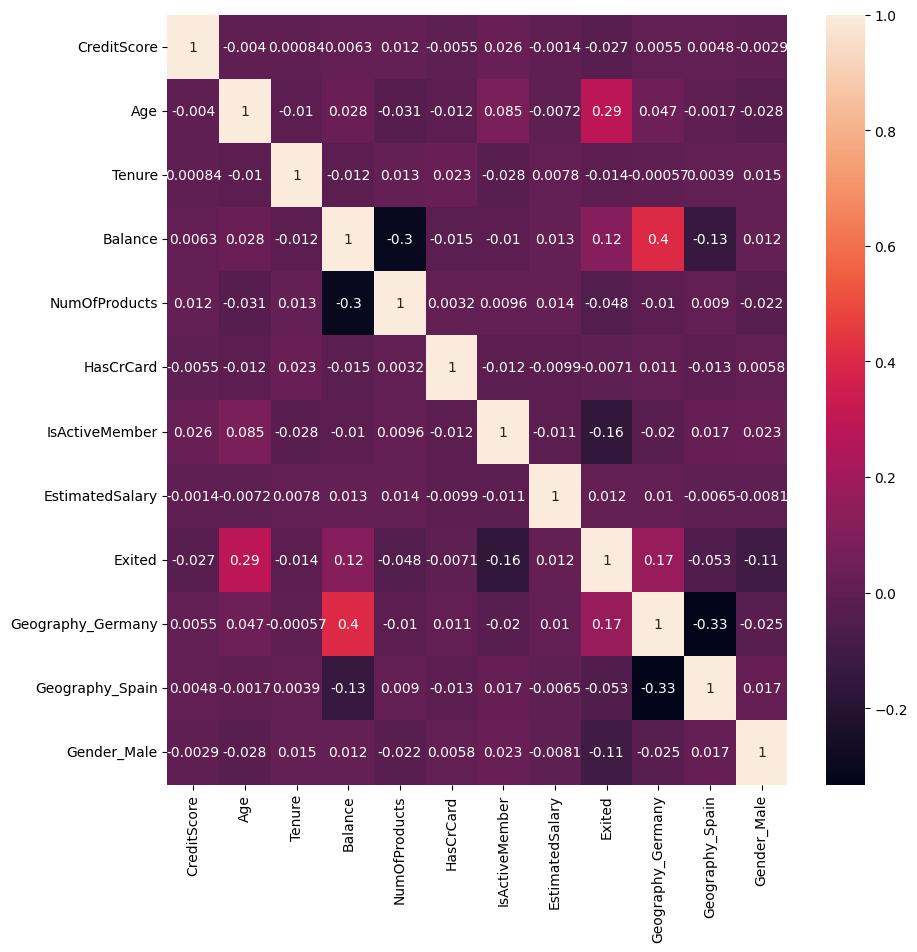

In [83]:
plt.figure(figsize=(10,10))
sns.heatmap(df.corr(),annot=True)
#

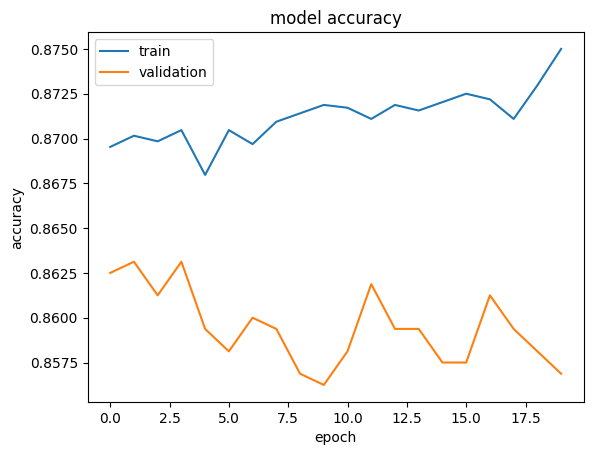

In [89]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')

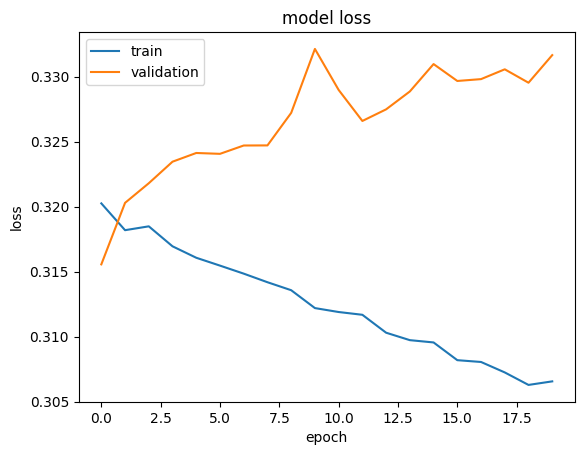

In [90]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')